## Importaciones

In [49]:
from __future__ import annotations

import time
from dataclasses import dataclass
from typing import Final, Any

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
BINANCE_BASE_URL: Final[str] = "https://api.binance.com"
KLINES_ENDPOINT: Final[str] = "/api/v3/klines"
START_DATE: Final[str] = "2023-03-01 00:00:00"
FINAL_DATE: Final[str] = "2026-03-01 00:00:00"

## Descarga de datos

Elegimos descarga de datos de Bitcoin desde la API de Binance. La temporalidad de los datos será de 5 minutos.

In [6]:
def download_btc_5m_simple(
    start: str = START_DATE,
    end: str = FINAL_DATE,
    symbol: str = "BTCUSDT",
    interval: str = "5m",
) -> pd.DataFrame:
    """
    Descarga velas de Binance y devuelve un DataFrame sencillo con:
    open_time, open, high, low, close, volume
    """
    start_ts = pd.Timestamp(start, tz="UTC")
    end_ts = pd.Timestamp(end, tz="UTC")

    if start_ts >= end_ts:
        raise ValueError("start debe ser anterior a end")

    start_ms = int(start_ts.timestamp() * 1000)
    end_ms = int(end_ts.timestamp() * 1000)
    step_ms = 5 * 60 * 1000  # 5 minutos

    rows_all = []

    with requests.Session() as session:
        current_start = start_ms

        while current_start < end_ms:
            response = session.get(
                f"{BINANCE_BASE_URL}{KLINES_ENDPOINT}",
                params={
                    "symbol": symbol,
                    "interval": interval,
                    "startTime": current_start,
                    "endTime": end_ms,
                    "limit": 1000,
                },
                timeout=30,
            )
            response.raise_for_status()
            rows = response.json()

            if not rows:
                break

            rows_all.extend(rows)

            last_open_time = int(rows[-1][0])
            current_start = last_open_time + step_ms

            time.sleep(0.15)

    df = pd.DataFrame(
        rows_all,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "quote_asset_volume",
            "number_of_trades",
            "taker_buy_base_volume",
            "taker_buy_quote_volume",
            "ignore",
        ],
    )

    if df.empty:
        raise ValueError("No se descargaron datos")

    df = df[["open_time", "open", "high", "low", "close", "volume"]].copy()

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)

    numeric_cols = ["open", "high", "low", "close", "volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)

    df = df.drop_duplicates(subset="open_time")
    df = df.sort_values("open_time").reset_index(drop=True)

    return df

In [7]:
df_btc = download_btc_5m_simple()
print(df_btc.head())
print(df_btc.shape)

                  open_time      open      high       low     close     volume
0 2023-03-01 00:00:00+00:00  23141.57  23178.71  23130.25  23178.71  990.65778
1 2023-03-01 00:05:00+00:00  23178.03  23183.13  23118.56  23120.06  826.75617
2 2023-03-01 00:10:00+00:00  23120.06  23171.67  23116.07  23159.91  858.93792
3 2023-03-01 00:15:00+00:00  23160.83  23185.64  23158.02  23183.94  705.74922
4 2023-03-01 00:20:00+00:00  23183.94  23219.99  23172.16  23201.88  934.12131
(315633, 6)


## Rellenamos gaps

Rellenamos gaps con ffil y volumen en 0 si no había dato.

In [10]:
def clean_gaps(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detecta gaps y los rellena.
    """
    df = df.copy()

    # Aseguramos orden temporal
    df = df.sort_values("open_time")

    # Usamos open_time como índice
    df = df.set_index("open_time")

    # Frecuencia esperada (5 minutos)
    full_index = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq="5min",
        tz="UTC"
    )

    # Reindex para detectar gaps
    df = df.reindex(full_index)

    # Marcar gaps
    df["is_gap"] = df["close"].isna()

    # Rellenar precios con último valor conocido
    price_cols = ["open", "high", "low", "close"]
    df[price_cols] = df[price_cols].ffill()

    # Volumen a 0 en gaps
    df["volume"] = df["volume"].fillna(0)

    df = df.reset_index().rename(columns={"index": "open_time"})

    return df

In [17]:
df_clean = clean_gaps(df_btc)

print(df_clean["is_gap"].sum())
print(df_clean[df_clean["is_gap"]]["open_time"].min(), df_clean[df_clean["is_gap"]]["open_time"].max())

16
2023-03-24 12:40:00+00:00 2023-03-24 13:55:00+00:00


Parece que todos los gaps están en el día 2023 03 24 entre las horas 12:40 y 13:55. Cuadra con una interrupción real de Binance Spot durante ese período.

En realidad la parada fue desde las 11:27, vamos a examinar.

In [19]:
start = "2023-03-24 11:27:00"
end = "2023-03-24 12:40:00"

df_window = df_clean[
    (df_clean["open_time"] >= start) &
    (df_clean["open_time"] <= end)
]

print(df_window)

                     open_time     open     high      low    close  volume  \
6762 2023-03-24 11:30:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6763 2023-03-24 11:35:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6764 2023-03-24 11:40:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6765 2023-03-24 11:45:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6766 2023-03-24 11:50:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6767 2023-03-24 11:55:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6768 2023-03-24 12:00:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6769 2023-03-24 12:05:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6770 2023-03-24 12:10:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6771 2023-03-24 12:15:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6772 2023-03-24 12:20:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6773 2023-03-24 12:25:00+00:00  28080.0  28080.0  28080.0  28080

In [20]:
start = "2023-03-24 11:27:00"
end = "2023-03-24 12:40:00"

df_window_btc = df_btc[
    (df_btc["open_time"] >= start) &
    (df_btc["open_time"] <= end)
]

print(df_window_btc)

                     open_time     open     high      low    close  volume
6762 2023-03-24 11:30:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6763 2023-03-24 11:35:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6764 2023-03-24 11:40:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6765 2023-03-24 11:45:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6766 2023-03-24 11:50:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6767 2023-03-24 11:55:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6768 2023-03-24 12:00:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6769 2023-03-24 12:05:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6770 2023-03-24 12:10:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6771 2023-03-24 12:15:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6772 2023-03-24 12:20:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6773 2023-03-24 12:25:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6774 2023-03-24 12:30:00+

Se ve que Binance ya rellenó esos huecos anteriores.

In [22]:
print(df_clean[df_clean['volume'] == 0]['open_time'].min(), df_clean[df_clean['volume'] == 0]['open_time'].max())

2023-03-24 11:30:00+00:00 2023-03-24 13:55:00+00:00


Perfecto y ese es el hueco

## Calculamos retornos

Calculamos retornos simple y logarítmicos

In [23]:
def compute_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detecta gaps, los rellena y calcula retornos.
    """
    df = df.copy()

    # Aseguramos orden temporal
    df = df.sort_values("open_time")

    # Usamos open_time como índice
    df = df.set_index("open_time")

    # Retornos simples
    df["ret_simple"] = df["close"].pct_change()

    # Retornos logarítmicos
    df["ret_log"] = np.log(df["close"]).diff()

    df = df.reset_index().rename(columns={"index": "open_time"})

    return df

In [24]:
df_clean = compute_returns(df_clean)

Veamos gráfico mínimo

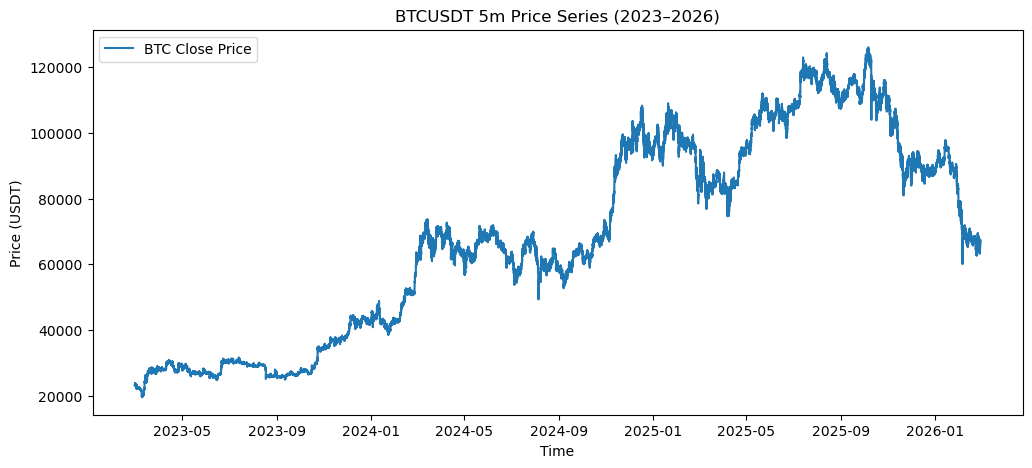

In [26]:
plt.figure(figsize=(12,5))

plt.plot(df_clean["open_time"], df_clean["close"], label="BTC Close Price")

plt.title("BTCUSDT 5m Price Series (2023–2026)")
plt.xlabel("Time")
plt.ylabel("Price (USDT)")
plt.legend()

plt.show()

## 1. Recoger datos en dollar bars, volumen bars, y tick bars.

Ahora mismo mis datos están en time bars, una fila cada 5 minutos. Para construir la microestructura perfecta debería bajarme cada transacción, así que construyo la aproximación considerando velas de 5 minutos como una observación.

Construyo un precio representativo

In [28]:
df_clean["typical_price"] = (
    df_clean["high"] + df_clean["low"] + df_clean["close"]
) / 3.0

Aproximo importe negociado usando OHLCV

In [29]:
df_clean["dollar_value"] = df_clean["typical_price"] * df_clean["volume"]

Cómo construiremos las barras:
* Tick bars: tomando como índice el open_time, pondremos el primer open, máximo high, mínimo low, últe, sumamos el volumen y el importe negociado
* Volume bars: acumulamos volumen fila a fila hasta superar un umbral y cierro la barra
* Dollar bars: igual que el volume bar pero el acumulado es monetario

Tick bars
* Cada barra contiene el mismo número de ejecuciones.
* Reducen la dependencia del reloj.

Volume bars
* Cada barra representa actividad homogénea en volumen.
* Cuando el mercado opera más, aparecen más barras.
* Suelen capturar mejor periodos intensos que las time bars.

Dollar bars
* Ajustan por el dinero negociado, no solo por unidades.
* En activos como BTCUSDT suelen ser especialmente útiles, porque el mismo volumen puede tener distinto significado según el precio.

In [33]:
def aggregate_ohlcv(group: pd.DataFrame) -> dict[str, Any]:
    """
    Agrega un bloque de filas a una sola barra OHLCV.
    """
    return {
        "open_time": group["open_time"].iloc[0],
        "open": group["open"].iloc[0],
        "high": group["high"].max(),
        "low": group["low"].min(),
        "close": group["close"].iloc[-1],
        "volume": group["volume"].sum(),
        "dollar_value": group["dollar_value"].sum(),
        "n_obs": len(group),
    }


def build_tick_bars(df: pd.DataFrame, ticks_per_bar: int) -> pd.DataFrame:
    """
    Construye tick bars aproximadas agrupando cada N velas.
    """
    if ticks_per_bar <= 0:
        raise ValueError("ticks_per_bar debe ser > 0")

    work = df.copy()
    work["bar_id"] = np.arange(len(work)) // ticks_per_bar

    bars = (
        work.groupby("bar_id", sort=True, as_index=False)
        .apply(lambda x: pd.Series(aggregate_ohlcv(x)))
        .reset_index(drop=True)
    )

    return bars


def build_imbalance_bars(
    df: pd.DataFrame,
    threshold: float,
    metric_col: str,
) -> pd.DataFrame:
    """
    Construye barras acumulando una métrica hasta alcanzar un umbral.

    metric_col puede ser:
    - 'volume' para volume bars
    - 'dollar_value' para dollar bars
    """
    if threshold <= 0:
        raise ValueError("threshold debe ser > 0")

    if metric_col not in {"volume", "dollar_value"}:
        raise ValueError("metric_col debe ser 'volume' o 'dollar_value'")

    work = df.copy()

    bars: list[dict[str, Any]] = []
    start_idx = 0
    acc_value = 0.0

    for i in range(len(work)):
        acc_value += float(work.loc[i, metric_col])

        if acc_value >= threshold:
            group = work.iloc[start_idx:i + 1]
            bars.append(aggregate_ohlcv(group))
            start_idx = i + 1
            acc_value = 0.0

    # Barra final incompleta, si existe
    if start_idx < len(work):
        group = work.iloc[start_idx:]
        bars.append(aggregate_ohlcv(group))

    return pd.DataFrame(bars)


def build_volume_bars(df: pd.DataFrame, volume_threshold: float) -> pd.DataFrame:
    """
    Construye volume bars.
    """
    return build_imbalance_bars(
        df=df,
        threshold=volume_threshold,
        metric_col="volume",
    )


def build_dollar_bars(df: pd.DataFrame, dollar_threshold: float) -> pd.DataFrame:
    """
    Construye dollar bars.
    """
    return build_imbalance_bars(
        df=df,
        threshold=dollar_threshold,
        metric_col="dollar_value",
    )

In [35]:
tick_bars = build_tick_bars(df_clean, ticks_per_bar=20)
volume_bars = build_volume_bars(df_clean, volume_threshold=5_000)
dollar_bars = build_dollar_bars(df_clean, dollar_threshold=100_000_000)

print("Tick bars:", tick_bars.shape)
print("Volume bars:", volume_bars.shape)
print("Dollar bars:", dollar_bars.shape)

Tick bars: (15783, 9)
Volume bars: (7853, 8)
Dollar bars: (20492, 8)


In [53]:
display(tick_bars.head())
display(volume_bars.head())
display(dollar_bars.head())

,bar_id,open_time,open,high,low,close,volume,dollar_value,n_obs,date
0,0,2023-03-01 00:00:00+00:00,23141.57,23278.00,23020.03,23242.52,20887.10552,4.834343e+08,20,2023-03-01
1,1,2023-03-01 01:40:00+00:00,23242.50,23498.00,23209.43,23418.87,18694.53990,4.359155e+08,20,2023-03-01
2,2,2023-03-01 03:20:00+00:00,23420.38,23847.00,23386.84,23794.48,23027.26067,5.426695e+08,20,2023-03-01
3,3,2023-03-01 05:00:00+00:00,23794.48,23821.56,23631.97,23754.36,19001.10655,4.505138e+08,20,2023-03-01
4,4,2023-03-01 06:40:00+00:00,23755.48,23803.39,23681.00,23766.22,19506.15387,4.629715e+08,20,2023-03-01


,open_time,open,high,low,close,volume,dollar_value,n_obs,date
0,2023-03-01 00:00:00+00:00,23141.57,23219.99,23116.07,23170.13,5003.71260,1.159246e+08,6,2023-03-01
1,2023-03-01 00:30:00+00:00,23170.13,23217.13,23023.00,23027.84,5880.21066,1.359055e+08,5,2023-03-01
2,2023-03-01 00:55:00+00:00,23028.77,23169.10,23020.03,23136.43,5738.07287,1.326061e+08,5,2023-03-01
3,2023-03-01 01:20:00+00:00,23137.28,23278.00,23123.01,23246.04,5696.61760,1.322609e+08,6,2023-03-01
4,2023-03-01 01:50:00+00:00,23245.38,23296.94,23231.29,23244.87,5319.08776,1.236997e+08,8,2023-03-01


,open_time,open,high,low,close,volume,dollar_value,n_obs,date
0,2023-03-01 00:00:00+00:00,23141.57,23219.99,23116.07,23170.13,5003.71260,1.159246e+08,6,2023-03-01
1,2023-03-01 00:30:00+00:00,23170.13,23217.13,23023.00,23027.84,5880.21066,1.359055e+08,5,2023-03-01
2,2023-03-01 00:55:00+00:00,23028.77,23166.03,23020.03,23163.84,4921.13018,1.136978e+08,4,2023-03-01
3,2023-03-01 01:15:00+00:00,23164.40,23278.00,23123.01,23242.52,5082.05208,1.179064e+08,5,2023-03-01
4,2023-03-01 01:40:00+00:00,23242.50,23296.94,23209.43,23244.55,4483.69305,1.042344e+08,6,2023-03-01


Vamos a visualizar dónde aparecen más barras

In [39]:
tick_bars["date"] = tick_bars["open_time"].dt.date
volume_bars["date"] = volume_bars["open_time"].dt.date
dollar_bars["date"] = dollar_bars["open_time"].dt.date

tick_daily = tick_bars.groupby("date").size()
volume_daily = volume_bars.groupby("date").size()
dollar_daily = dollar_bars.groupby("date").size()

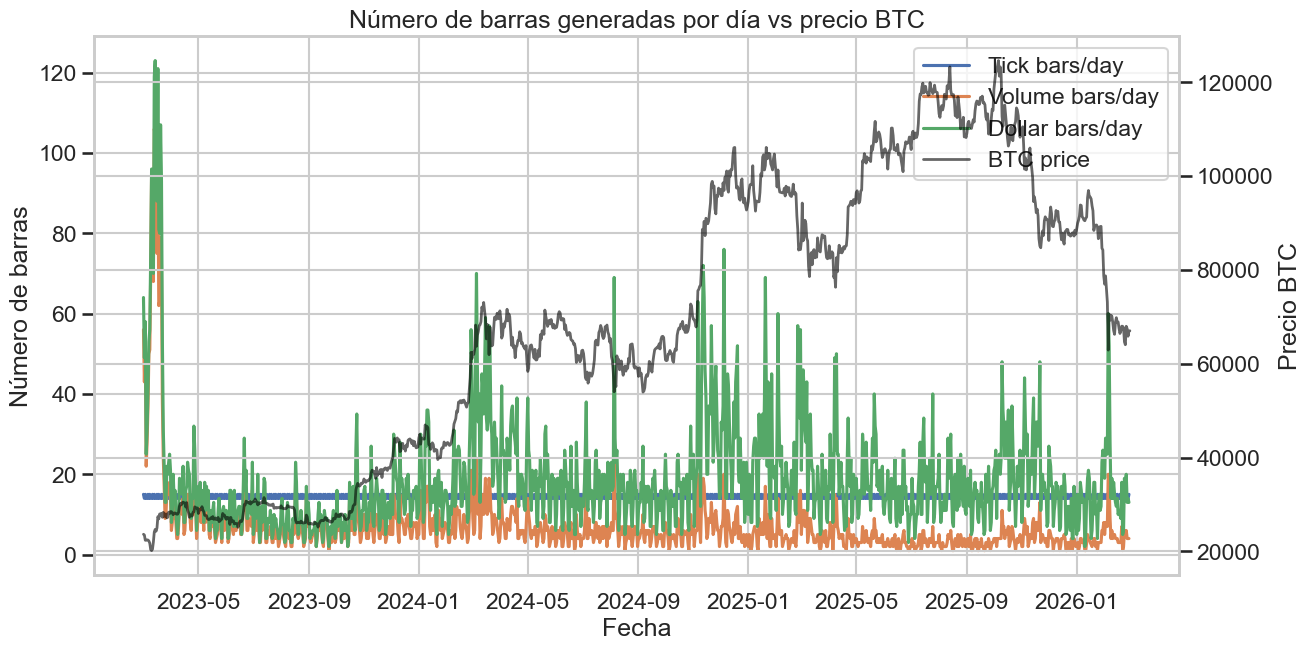

In [51]:
fig, ax1 = plt.subplots(figsize=(14,7))

# --- barras por día ---
ax1.plot(tick_daily.index, tick_daily.values, label="Tick bars/day")
ax1.plot(volume_daily.index, volume_daily.values, label="Volume bars/day")
ax1.plot(dollar_daily.index, dollar_daily.values, label="Dollar bars/day")

ax1.set_title("Número de barras generadas por día vs precio BTC")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Número de barras")
ax1.grid(True)

# --- serie real (precio) ---
ax2 = ax1.twinx()

price_daily = df_clean.set_index("open_time")["close"].resample("D").last()

ax2.plot(
    price_daily.index,
    price_daily.values,
    color="black",
    linewidth=2,
    alpha=0.6,
    label="BTC price"
)

ax2.set_ylabel("Precio BTC")

# --- leyenda conjunta ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.show()

Las barras por volumen y por dólares representan mucho mejor los movimientos del mercado, siendo más estables si se visualizan teniendo en cuenta sus valores

Vamos a ver el día de enero de 2026 que hubo más movimiento cómo fue

Peor día reciente: 2026-02-05
Retorno diario: -14.0174%


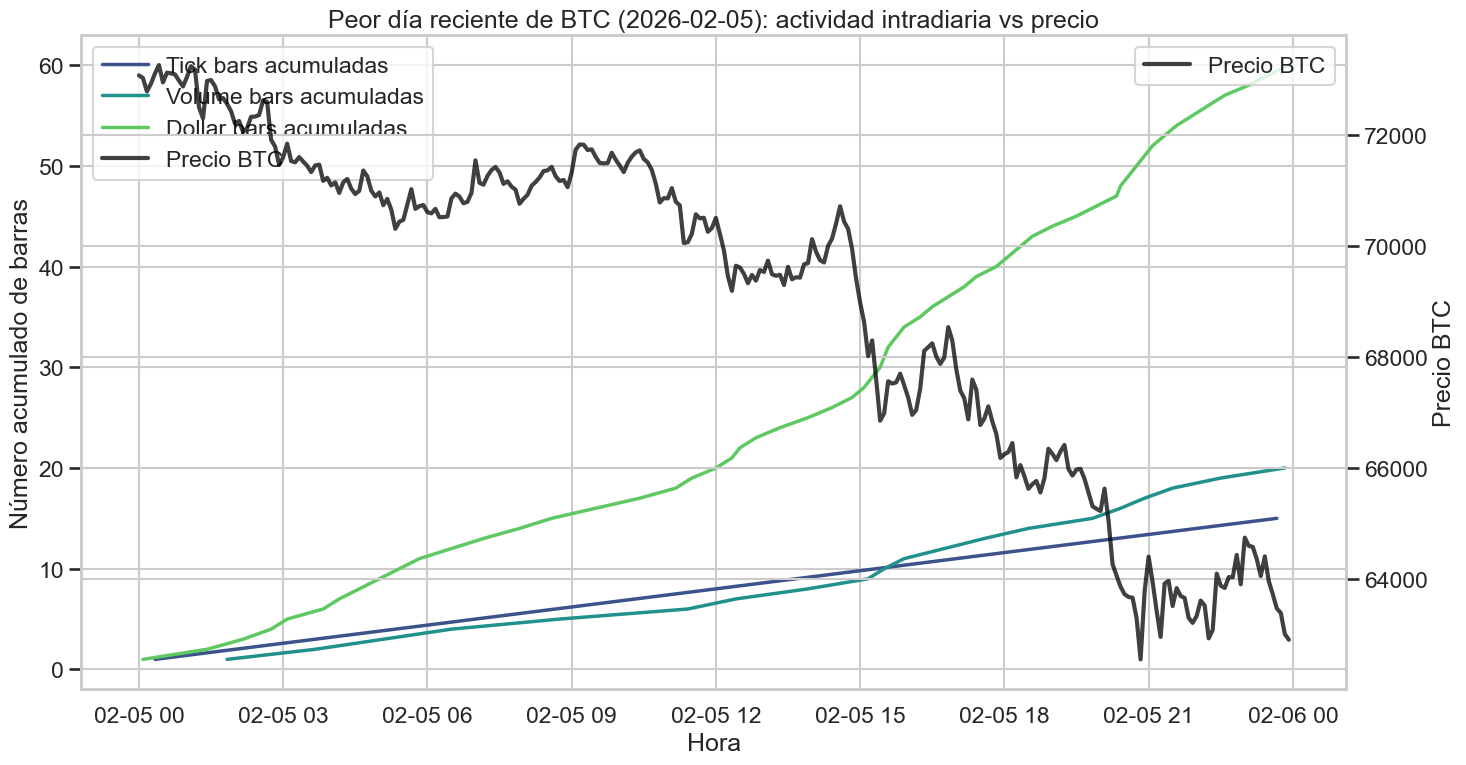

In [54]:

sns.set_theme(style="whitegrid", context="talk")


# =========================
# 1) Encontrar el peor día reciente
# =========================
price_daily = (
    df_clean
    .set_index("open_time")["close"]
    .resample("D")
    .last()
)

daily_returns = price_daily.pct_change()

# Peor día de los últimos 90 días
recent_window = 90
recent_returns = daily_returns[
    daily_returns.index >= daily_returns.index.max() - pd.Timedelta(days=recent_window)
]

worst_day = recent_returns.idxmin().normalize()
next_day = worst_day + pd.Timedelta(days=1)

print(f"Peor día reciente: {worst_day.date()}")
print(f"Retorno diario: {recent_returns.loc[worst_day]:.4%}")


# =========================
# 2) Precio intradiario real de ese día
# =========================
price_intraday = df_clean[
    (df_clean["open_time"] >= worst_day) &
    (df_clean["open_time"] < next_day)
].copy()


# =========================
# 3) Función helper para barras acumuladas intradía
# =========================
def cumulative_bars_in_day(
    bars_df: pd.DataFrame,
    day_start: pd.Timestamp,
) -> pd.DataFrame:
    """
    Filtra las barras de un día concreto y crea el conteo acumulado.
    """
    day_end = day_start + pd.Timedelta(days=1)

    out = bars_df[
        (bars_df["open_time"] >= day_start) &
        (bars_df["open_time"] < day_end)
    ].copy()

    out = out.sort_values("open_time").reset_index(drop=True)
    out["cum_count"] = range(1, len(out) + 1)

    return out


tick_intraday = cumulative_bars_in_day(tick_bars, worst_day)
volume_intraday = cumulative_bars_in_day(volume_bars, worst_day)
dollar_intraday = cumulative_bars_in_day(dollar_bars, worst_day)


# =========================
# 4) Gráfico bonito
# =========================
fig, ax1 = plt.subplots(figsize=(15, 8))

palette = sns.color_palette("viridis", 3)

sns.lineplot(
    data=tick_intraday,
    x="open_time",
    y="cum_count",
    ax=ax1,
    linewidth=2.5,
    color=palette[0],
    label="Tick bars acumuladas",
)

sns.lineplot(
    data=volume_intraday,
    x="open_time",
    y="cum_count",
    ax=ax1,
    linewidth=2.5,
    color=palette[1],
    label="Volume bars acumuladas",
)

sns.lineplot(
    data=dollar_intraday,
    x="open_time",
    y="cum_count",
    ax=ax1,
    linewidth=2.5,
    color=palette[2],
    label="Dollar bars acumuladas",
)

ax1.set_title(
    f"Peor día reciente de BTC ({worst_day.date()}): "
    "actividad intradiaria vs precio"
)
ax1.set_xlabel("Hora")
ax1.set_ylabel("Número acumulado de barras")


# Eje secundario para el precio
ax2 = ax1.twinx()

sns.lineplot(
    data=price_intraday,
    x="open_time",
    y="close",
    ax=ax2,
    color="black",
    linewidth=3,
    alpha=0.75,
    label="Precio BTC",
)

ax2.set_ylabel("Precio BTC")


# Leyenda conjunta
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

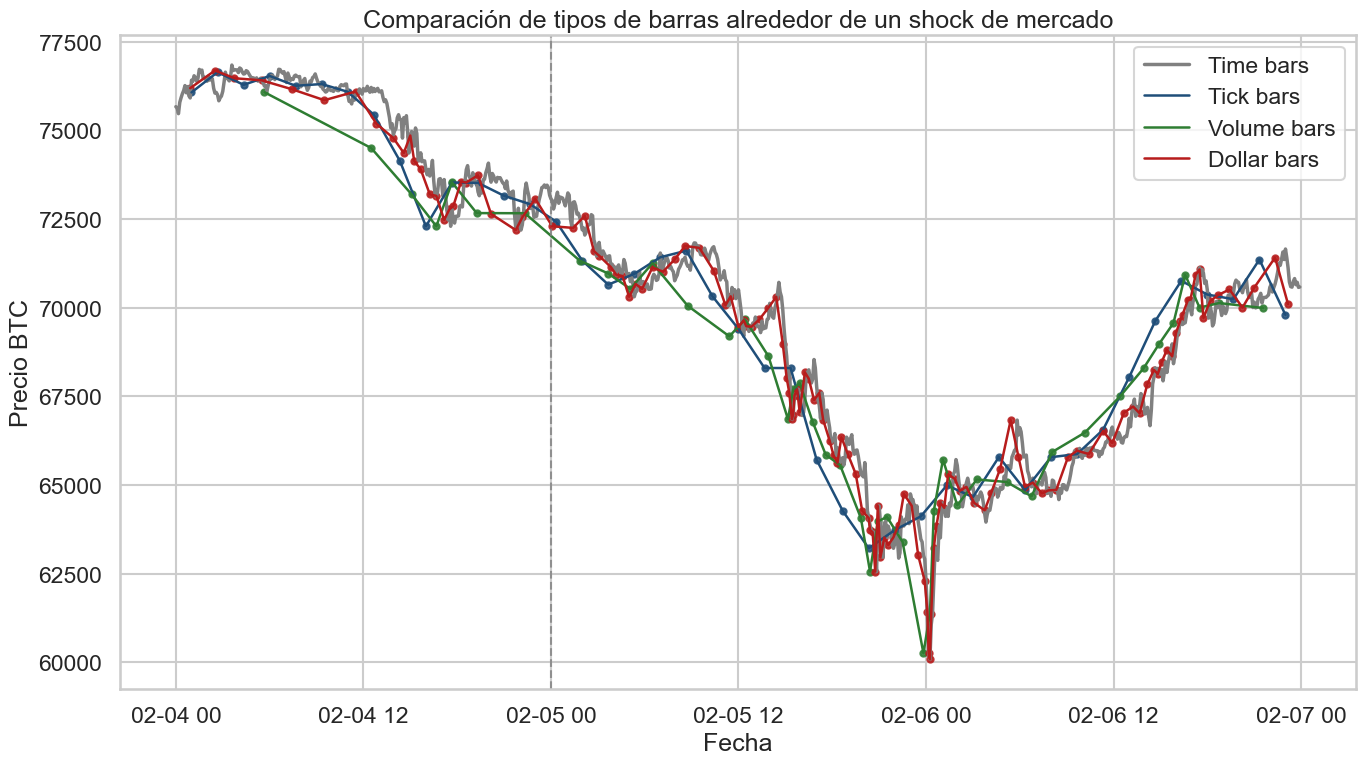

In [59]:

sns.set_theme(style="whitegrid", context="talk")

# ======================
# 1) Detectar día de caída fuerte reciente
# ======================
price_daily = (
    df_clean
    .set_index("open_time")["close"]
    .resample("D")
    .last()
)

daily_returns = price_daily.pct_change()

recent_returns = daily_returns[
    daily_returns.index >= daily_returns.index.max() - pd.Timedelta(days=90)
]

shock_day = recent_returns.idxmin().normalize()

# ======================
# 2) Ventana corta (±1 día)
# ======================
start_window = shock_day - pd.Timedelta(days=1)
end_window = shock_day + pd.Timedelta(days=2)

time_plot = df_clean[
    (df_clean["open_time"] >= start_window) &
    (df_clean["open_time"] < end_window)
]

tick_plot = tick_bars[
    (tick_bars["open_time"] >= start_window) &
    (tick_bars["open_time"] < end_window)
]

volume_plot = volume_bars[
    (volume_bars["open_time"] >= start_window) &
    (volume_bars["open_time"] < end_window)
]

dollar_plot = dollar_bars[
    (dollar_bars["open_time"] >= start_window) &
    (dollar_bars["open_time"] < end_window)
]

# ======================
# 3) Gráfico
# ======================
plt.figure(figsize=(14,8))

# colores sobrios
color_time = "gray"
color_tick = "#1f4e79"
color_volume = "#2e7d32"
color_dollar = "#b71c1c"

# ----- líneas -----
sns.lineplot(data=time_plot, x="open_time", y="close",
             color=color_time, linewidth=2.5, label="Time bars")

sns.lineplot(data=tick_plot, x="open_time", y="close",
             color=color_tick, linewidth=1.8, label="Tick bars")

sns.lineplot(data=volume_plot, x="open_time", y="close",
             color=color_volume, linewidth=1.8, label="Volume bars")

sns.lineplot(data=dollar_plot, x="open_time", y="close",
             color=color_dollar, linewidth=1.8, label="Dollar bars")

# ----- puntos -----
plt.scatter(tick_plot["open_time"], tick_plot["close"],
            s=20, color=color_tick, alpha=0.85)

plt.scatter(volume_plot["open_time"], volume_plot["close"],
            s=20, color=color_volume, alpha=0.85)

plt.scatter(dollar_plot["open_time"], dollar_plot["close"],
            s=20, color=color_dollar, alpha=0.85)

# marcar el día del shock
plt.axvline(shock_day, linestyle="--", color="gray", linewidth=1.5, alpha=0.8)

plt.title("Comparación de tipos de barras alrededor de un shock de mercado")
plt.xlabel("Fecha")
plt.ylabel("Precio BTC")

plt.legend()
plt.tight_layout()
plt.show()

Analicemos finalmente la distribución de los retornos para comprobar la mayor estabilidad de la serie cuando no se mide por tiempo

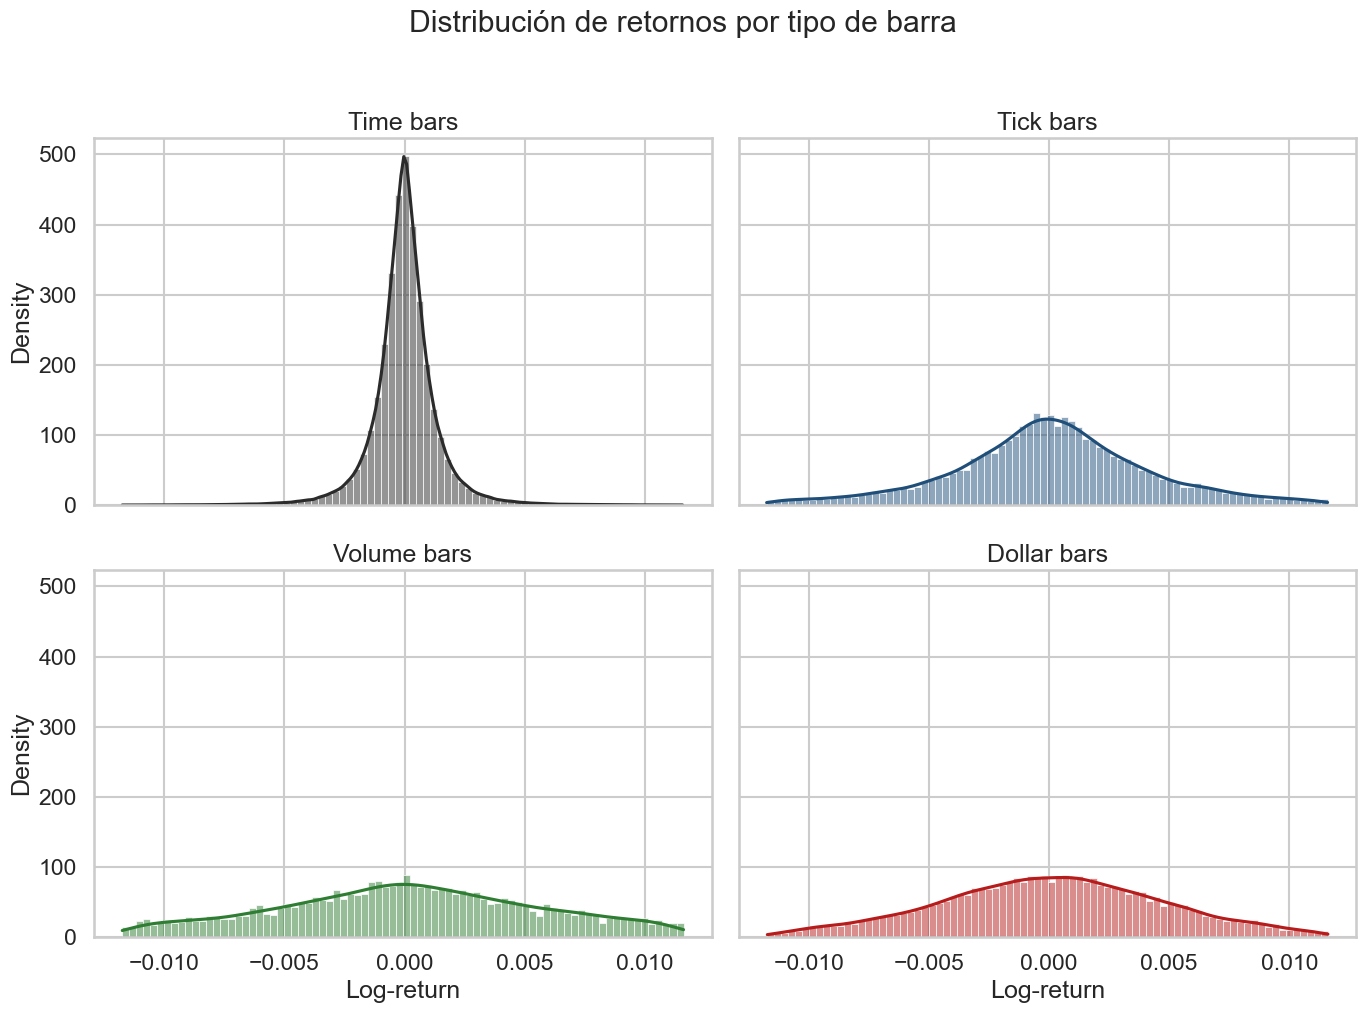

In [60]:

sns.set_theme(style="whitegrid", context="talk")

# ======================
# 1) Retornos logarítmicos
# ======================
def log_returns(df: pd.DataFrame) -> pd.Series:
    s = (
        df.sort_values("open_time")["close"]
        .astype(float)
        .pipe(np.log)
        .diff()
        .dropna()
    )
    return s

ret_time = log_returns(df_clean)
ret_tick = log_returns(tick_bars)
ret_volume = log_returns(volume_bars)
ret_dollar = log_returns(dollar_bars)

# ======================
# 2) Rango común para histogramas
# (recortamos outliers extremos para que se vea bien)
# ======================
all_rets = pd.concat([ret_time, ret_tick, ret_volume, ret_dollar], axis=0)
q_low, q_high = all_rets.quantile([0.005, 0.995])  # 0.5%–99.5%
bins = 80

# ======================
# 3) Subplots comparables
# ======================
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

plots = [
    (ret_time,   "Time bars",   "#2b2b2b"),
    (ret_tick,   "Tick bars",   "#1f4e79"),
    (ret_volume, "Volume bars", "#2e7d32"),
    (ret_dollar, "Dollar bars", "#b71c1c"),
]

for ax, (series, title, color) in zip(axes.ravel(), plots):
    sns.histplot(
        series[(series >= q_low) & (series <= q_high)],
        bins=bins,
        stat="density",
        kde=True,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Log-return")
    ax.set_ylabel("Density")

plt.suptitle("Distribución de retornos por tipo de barra", y=1.02)
plt.tight_layout()
plt.show()

Finalmente compararemos una semana mala vs una semana buena

Peor mes móvil:
Inicio: 2026-01-07 | Fin: 2026-02-05 | Retorno: -32.89%
Mejor mes móvil:
Inicio: 2024-02-04 | Fin: 2024-03-04 | Retorno: 58.67%


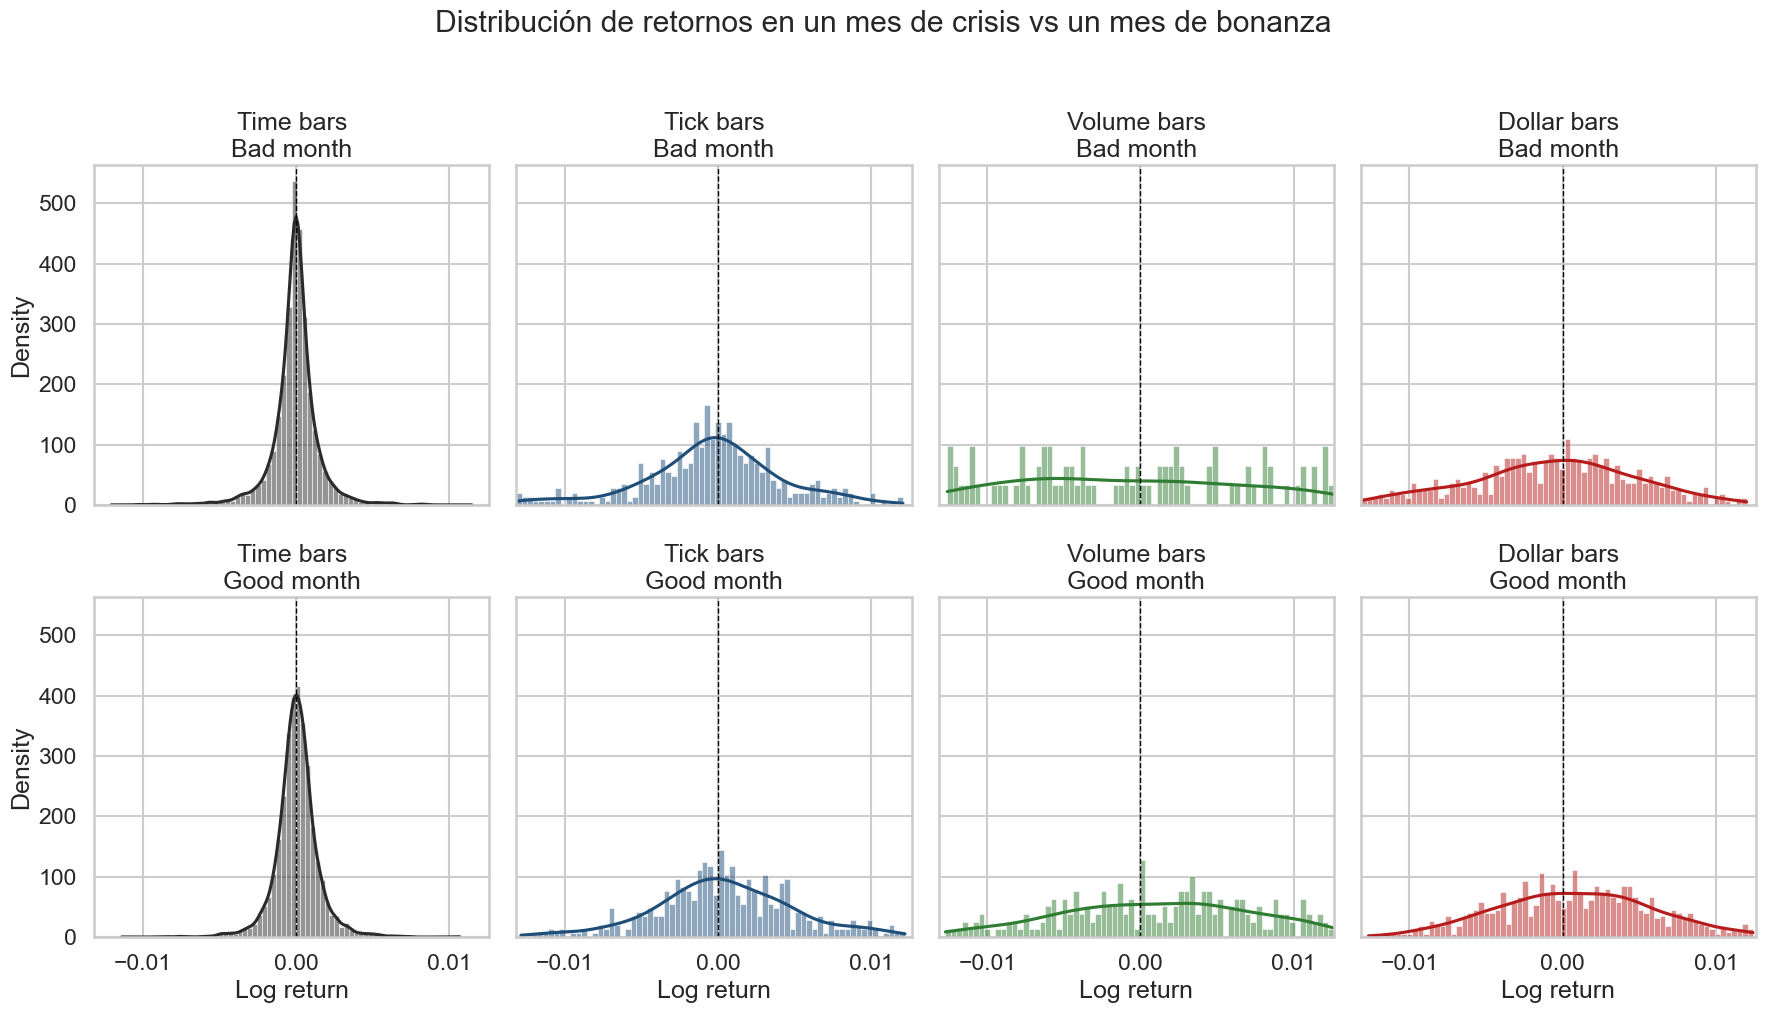

In [63]:

sns.set_theme(style="whitegrid", context="talk")

# ======================
# 1) precio diario
# ======================
price_daily = (
    df_clean
    .set_index("open_time")["close"]
    .resample("D")
    .last()
)

# ======================
# 2) detectar mejor y peor mes móvil de 30 días
# ======================
monthly_perf = price_daily / price_daily.shift(30) - 1.0

bad_month_end = monthly_perf.idxmin().normalize()
good_month_end = monthly_perf.idxmax().normalize()

bad_start = bad_month_end - pd.Timedelta(days=29)
bad_end = bad_month_end + pd.Timedelta(days=1)

good_start = good_month_end - pd.Timedelta(days=29)
good_end = good_month_end + pd.Timedelta(days=1)

print("Peor mes móvil:")
print("Inicio:", bad_start.date(), "| Fin:", (bad_end - pd.Timedelta(days=1)).date(),
      "| Retorno:", f"{monthly_perf.loc[bad_month_end]:.2%}")

print("Mejor mes móvil:")
print("Inicio:", good_start.date(), "| Fin:", (good_end - pd.Timedelta(days=1)).date(),
      "| Retorno:", f"{monthly_perf.loc[good_month_end]:.2%}")


# ======================
# 3) función de retornos
# ======================
def compute_log_returns(df: pd.DataFrame) -> pd.Series:
    return (
        df.sort_values("open_time")["close"]
        .astype(float)
        .pipe(np.log)
        .diff()
        .dropna()
    )


def window_returns(
    df: pd.DataFrame,
    start: pd.Timestamp,
    end: pd.Timestamp,
) -> pd.Series:
    window = df[
        (df["open_time"] >= start) &
        (df["open_time"] < end)
    ].copy()

    return compute_log_returns(window)


# ======================
# 4) retornos en cada mes
# ======================
bad_returns = {
    "Time bars": window_returns(df_clean, bad_start, bad_end),
    "Tick bars": window_returns(tick_bars, bad_start, bad_end),
    "Volume bars": window_returns(volume_bars, bad_start, bad_end),
    "Dollar bars": window_returns(dollar_bars, bad_start, bad_end),
}

good_returns = {
    "Time bars": window_returns(df_clean, good_start, good_end),
    "Tick bars": window_returns(tick_bars, good_start, good_end),
    "Volume bars": window_returns(volume_bars, good_start, good_end),
    "Dollar bars": window_returns(dollar_bars, good_start, good_end),
}


# ======================
# 5) rango común para comparar bien
# ======================
all_rets = pd.concat(
    [
        *bad_returns.values(),
        *good_returns.values(),
    ],
    axis=0
)

x_low, x_high = all_rets.quantile([0.005, 0.995])


# ======================
# 6) gráfico
# ======================
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

colors = {
    "Time bars": "#2b2b2b",
    "Tick bars": "#1f4e79",
    "Volume bars": "#2e7d32",
    "Dollar bars": "#b71c1c",
}

# fila superior: mes malo
for i, (label, series) in enumerate(bad_returns.items()):
    sns.histplot(
        series[(series >= x_low) & (series <= x_high)],
        bins=70,
        kde=True,
        stat="density",
        color=colors[label],
        ax=axes[0, i],
        edgecolor="white",
        linewidth=0.4,
    )
    axes[0, i].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[0, i].set_title(f"{label}\nBad month")

# fila inferior: mes bueno
for i, (label, series) in enumerate(good_returns.items()):
    sns.histplot(
        series[(series >= x_low) & (series <= x_high)],
        bins=70,
        kde=True,
        stat="density",
        color=colors[label],
        ax=axes[1, i],
        edgecolor="white",
        linewidth=0.4,
    )
    axes[1, i].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[1, i].set_title(f"{label}\nGood month")

for ax in axes.flatten():
    ax.set_xlabel("Log return")
    ax.set_ylabel("Density")
    ax.set_xlim(x_low, x_high)

plt.suptitle(
    "Distribución de retornos en un mes de crisis vs un mes de bonanza",
    y=1.02
)

plt.tight_layout()
plt.show()

## 2. Procesar los datos haciendo diferenciación fraccional con varios ‘d’.